# **Урок 4**. Подружимся с CLIP 


Из лекции мы с вами узнали, что ```CLIP``` подход дружит между собой текстовый и картиночный домены. Ну а мы сегодня попробуем подружиться с ```CLIP```-ом. 

## **План**

1. Знакомимся с ```CLIP```-моделями
2. Пробуем классифицировать дорожные знаки zero-shot

Дружиться мы будем с open-source имплементацией CLIP - [open_clip](https://github.com/mlfoundations/open_clip).

## **1. Знакомимся с CLIP-моделями**

In [1]:
# для начала установим себе open_clip
%pip install open_clip_torch 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import cv2
import tqdm
import glob
import torch
import open_clip
import pandas as pd
import numpy as np
import IPython.display
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore')

Давайте посмотрим, какие модельки нам доступны. 

In [3]:
# формат тут такой: ('имя модельки', 'её претрейн')
print(open_clip.list_pretrained())
print('Number of models: {}'.format(len(open_clip.list_pretrained())))

[('RN50', 'openai'), ('RN50', 'yfcc15m'), ('RN50', 'cc12m'), ('RN101', 'openai'), ('RN101', 'yfcc15m'), ('RN50x4', 'openai'), ('RN50x16', 'openai'), ('RN50x64', 'openai'), ('ViT-B-32', 'openai'), ('ViT-B-32', 'laion400m_e31'), ('ViT-B-32', 'laion400m_e32'), ('ViT-B-32', 'laion2b_e16'), ('ViT-B-32', 'laion2b_s34b_b79k'), ('ViT-B-32', 'datacomp_xl_s13b_b90k'), ('ViT-B-32', 'datacomp_m_s128m_b4k'), ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'), ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'), ('ViT-B-32', 'commonpool_m_image_s128m_b4k'), ('ViT-B-32', 'commonpool_m_text_s128m_b4k'), ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'), ('ViT-B-32', 'commonpool_m_s128m_b4k'), ('ViT-B-32', 'datacomp_s_s13m_b4k'), ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'), ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'), ('ViT-B-32', 'commonpool_s_image_s13m_b4k'), ('ViT-B-32', 'commonpool_s_text_s13m_b4k'), ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'), ('ViT-B-32', 'commonpool_s_s13m_b4k'), ('ViT-B-32', 'metaclip_400m'), ('V

Как же из всего этого многообразия что-то выбирать?

Лидерборд из большинства представленных моделей можно найти в [документации репозитория](https://github.com/mlfoundations/open_clip/blob/main/docs/openclip_classification_results.csv). 

Сети здесь тестировались в ```zero-shot``` постановке на 35 ```fine-grained``` датасетах. 
Если про какой-то из них вы знаете, что он близок по домену к вашим данным - ориентируйтесь на точность по этому датасету. Мне вот, например, в рабочие будни ```Stanford Cars``` очень релевантен. Для задачи же классификации мелких картинок цветных дорожных знаков на большое количество классов смотреть стоит скорее на ```CIFAR-100```. 

Если про эти датасеты вы ничего не знаете, можно выбирать сетку по соотношению ```Accuracy```-```FLOPS```, чтобы за приемлемое время получить необходимые вам предсказания. 

Ещё информацию о некоторых предтренированных моделях можно найти [тут](https://github.com/mlfoundations/open_clip/blob/main/docs/PRETRAINED.md). 

На ```CIFAR-100``` классно выглядит ```('EVA02-E-14-plus', 'laion2b_s9b_b144k')``` - ```acc=0.9316```, но она прям очень жирненькая - ```2362.19 GFLOPs```, ```5044.89 M Params```, мы такую не потянем.

Давайте возьмем модельку существенно меньше - зато топ-1 в среднем - ```('ViT-H-14-378-quickgelu', 'dfn5b')``` - ```acc=0.9043```, ```1054.05 GFLOPs```, ```986.71 M Params```.

In [4]:
# посмотрим, сколько ресурсов нам доступно
! nvidia-smi

Wed May 20 13:10:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# указала, какую карточку надо использовать
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [6]:
# создаем модельку
model, _, preprocess = open_clip.create_model_and_transforms('ViT-H-14-378-quickgelu', pretrained='dfn5b', device='cuda')

open_clip_pytorch_model.bin:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

In [7]:
# посмотрим как теперь с памятью дела
! nvidia-smi

Wed May 20 13:11:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             26W /   70W |    3991MiB /  15360MiB |     24%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Супер, модель заняла не очень много памяти, нам бы и 11Гб хватило.

In [8]:
# давайте посмотрим на параметры модели
model.eval()
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Context length:", context_length)
print("Vocab size:", vocab_size)

Model parameters: 986,714,881
Context length: 77
Vocab size: 49408


Второй объект, который мы получили при инициализации - это ```transform```, который ожидает данная модель. Именно с ним надо будет готовить картинки. 

In [9]:
# давайте на него посмотрим
preprocess

Compose(
    Resize(size=(378, 378), interpolation=bicubic, max_size=None, antialias=True)
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

Ну а теперь получим эмбеддинг для какой-нибудь картинки:

In [14]:
img_test = Image.open('/kaggle/input/datasets/andreykurdyubov/signs-cv2/signs/TEST/37/042_0001_j.png')

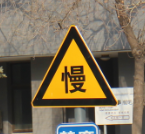

In [15]:
img_test

In [18]:
# преобразовали картинку и сделали тензор 4-мерным - добавили размерность батчей
img_tensor = preprocess(img_test).unsqueeze(0).float()

In [19]:
img_tensor.shape

torch.Size([1, 3, 378, 378])

In [20]:
def myshow(img, 
           means=(0.48145466, 0.4578275, 0.40821073), 
           stds=(0.26862954, 0.26130258, 0.27577711)):
    means_t = torch.tensor(means)
    stds_t = torch.tensor(stds)
    img = img * stds_t.view(-1, 1, 1) + means_t.view(-1, 1, 1) # умножаем на std, прибавляем mean - в Normalize всё наоборот
    npimg = img.detach().numpy()
    fig = plt.figure(figsize=(4, 4))
    plt.imshow(npimg.transpose(1, 2, 0))

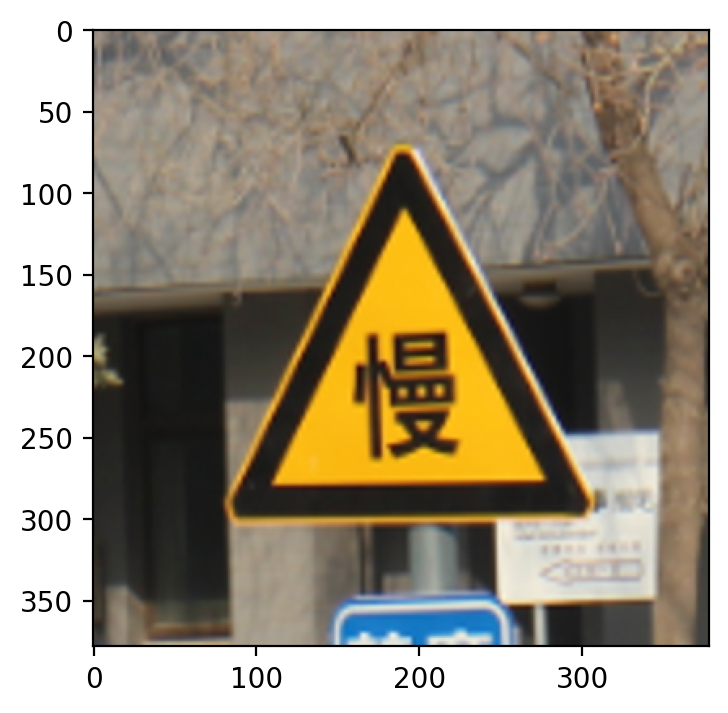

In [21]:
myshow(img_tensor[0])

In [27]:
image_features = model.encode_image(img_tensor.cuda()).float()
image_features = image_features.cpu().detach()

In [28]:
image_features.shape

torch.Size([1, 1024])

Итак, с картинками понятно: 
- мы будем брать их из нашего датасета, 
- трансформировать с помощью ```preprocess```, 
- кормить сетке, 
- получать вектора-эмбеддинги длины 1024,
- успех!

Работая с ```CLIP```, мы также будем взаимодействовать с текстовыми описаниями классов. Как же это сделать?

В целом всё просто. Надо получить из текста токены (как будто бы ```preproc``` использовать), а дальше то же, что с картинками. 

Будем использовать готовый токенайзер, который используется всегда и везде (с ним ```СLIP```-модельки и обучались):

In [29]:
from open_clip import tokenizer

In [30]:
# просто используем метод tokenize на интересующей нас строке
text_token = tokenizer.tokenize("Hello Kapov.Courses!")

In [31]:
# длина падится нулями до 77, которую и ожидает CLIP
print(text_token)
print(text_token.shape)

tensor([[49406,  3306,  1595, 25731,   269,  9464,   256, 49407,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]])
torch.Size([1, 77])


Полученные токены мы отдаем ```text encoder```-у внутри ```CLIP```-а и получаем эмбеддинг:

In [32]:
text_features = model.encode_text(text_token.cuda()).float()

In [33]:
text_features.shape

torch.Size([1, 1024])

Размер эмбеддинга текста точно такой же, как у картинки. Это совершенно не случайно - нам же ещё их скалярное произведение для оценки похожести считать. 

Ну что ж, как звать модельку и отдельные её методы, мы узнали. 

## **2. Пробуем классифицировать дорожные знаки zero-shot**

Давайте попробуем поклассифицировать наши дорожные знаки в zero-shot постановке. 

Классов у нас довольно много, а описаний для них нет, так что давайте ограничимся только первыми 8-ю - знаками ограничения скорости. 

Нам понадобится только TESTSET, ведь учить мы ничего не будем. Для начала заведем для него датафрейм.

In [34]:
all_test_files = []

for i in range(8):
    all_test_files += sorted(glob.glob(f'/kaggle/input/datasets/andreykurdyubov/signs-cv2/signs/TEST/{i}/*'))

test_classes = [int(x.split('/')[-2]) for x in all_test_files]
test_df = pd.DataFrame(zip(all_test_files, test_classes), columns=['imname', 'class'])

In [35]:
test_df

,imname,class
0,/kaggle/input/datasets/andreykurdyubov/signs-c...,0
1,/kaggle/input/datasets/andreykurdyubov/signs-c...,0
2,/kaggle/input/datasets/andreykurdyubov/signs-c...,0
3,/kaggle/input/datasets/andreykurdyubov/signs-c...,0
4,/kaggle/input/datasets/andreykurdyubov/signs-c...,0
...,...,...
192,/kaggle/input/datasets/andreykurdyubov/signs-c...,7
193,/kaggle/input/datasets/andreykurdyubov/signs-c...,7
194,/kaggle/input/datasets/andreykurdyubov/signs-c...,7
195,/kaggle/input/datasets/andreykurdyubov/signs-c...,7


Ну не много у нас примеров :) 

Посмотрим, где какое ограничение скорости написано:

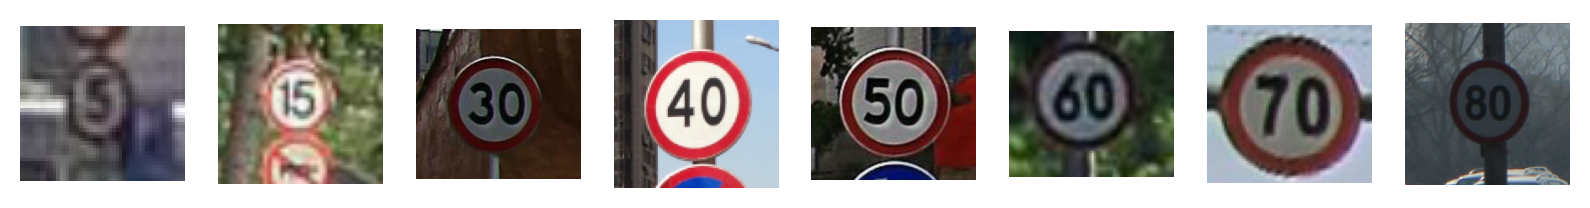

In [36]:
fig, ax = plt.subplots(1, 8, figsize=(10, 15))

for i in range(8):
    subset = test_df[test_df['class'] == i]
    imname = subset['imname'].values[:1][0]
    ax[i].imshow(cv2.imread(imname)[:, :, ::-1])
    ax[i].axis('off')

Интересное распределение классов, ну да ладно. 

In [82]:
# заведем список с опциями классов
test_labels = ['5', '15', '30', '40', '50', '60', '70', '80']

In [66]:
# придумаем текстовые описания, которые будем показывать сети
text_descriptions = (f'a photo of a road sign with number {label}' for label in test_labels)

In [67]:
text_descriptions

('a photo of a road sign with number 5',
 'a photo of a road sign with number 20',
 'a photo of a road sign with number 30',
 'a photo of a road sign with number 40',
 'a photo of a road sign with number 50',
 'a photo of a road sign with number 60',
 'a photo of a road sign with number 70',
 'a photo of a road sign with number 80')

In [68]:
# получим токены
text_tokens = tokenizer.tokenize(text_descriptions)

In [69]:
# текстовых описаний мало, для них мы один раз получим эмбеддинги
with torch.no_grad():
    text_features = model.encode_text(text_tokens.cuda()).float()

# обязательно их нормализуем, чтобы вектор оказался на едииничной сфере
text_features /= text_features.norm(dim=-1, keepdim=True)

In [70]:
# проверим размерности
text_features.shape

torch.Size([8, 1024])

Теперь посчитаем эмбеддинги для всех наших картинок в test_df:

In [71]:
image_features = []

for i, row in tqdm.tqdm(test_df.iterrows()):
    image = Image.open(row['imname'])
    img_tensor = preprocess(image).unsqueeze(0).float()
    with torch.no_grad():
        image_feature = model.encode_image(img_tensor.cuda()).float()
    image_features += image_feature

# из листа делаем тензор
image_features = torch.stack(image_features)

# обязательно нормализуем
image_features /= image_features.norm(dim=-1, keepdim=True)

197it [01:02,  3.16it/s]


In [72]:
# проверим, что всё в  порядке
image_features.shape

torch.Size([197, 1024])

Теперь посчитаем все попарные скалярные произведения, у нас должна получиться матрица ```197x8```:

In [73]:
# по размерности текстов берем softmax - так мы распределим вероятности и сможем выбрать самый вероятный класс
text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

In [74]:
text_probs.shape

torch.Size([197, 8])

Отлично, всё так!

In [75]:
# по текстовой размерности выбираем максимальный элемент и его индекс
scores, preds = torch.max(text_probs, dim=-1)

Добавим эти данные в наш датафрейм с тестом:

In [76]:
test_df['pred'] = preds.cpu()
test_df['score'] = scores.cpu()

Давайте теперь визуализируем, что у нас получилось:

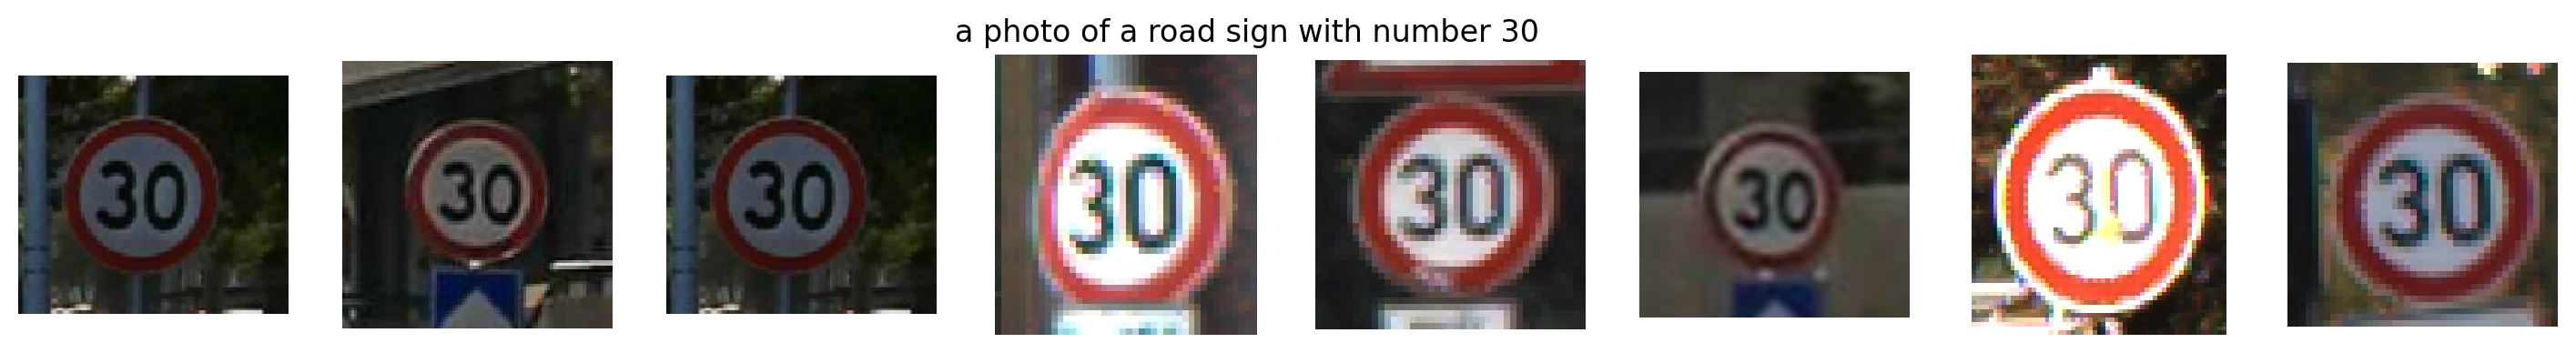

In [81]:
i = 2

fig, ax = plt.subplots(1, 8, figsize=(18, 2))
pred_df = test_df[test_df['pred'] == i] # выбираем картинки с предсказанным i-м классом
df_to_vis = pred_df.sample(8, replace=True)
df_to_vis.reset_index(inplace=True, drop=True)

for j, row in df_to_vis.iterrows():
    image = cv2.imread(row['imname'])
    ax[j].imshow(image[:, :, ::-1])
    ax[j].axis("off")
    
plt.suptitle(text_descriptions[i])
plt.show()

In [78]:
test_df[test_df['pred'] != test_df['class']]

,imname,class,pred,score
7,/kaggle/input/datasets/andreykurdyubov/signs-c...,1,0,0.724106
8,/kaggle/input/datasets/andreykurdyubov/signs-c...,1,0,0.956601
9,/kaggle/input/datasets/andreykurdyubov/signs-c...,1,0,0.967484
10,/kaggle/input/datasets/andreykurdyubov/signs-c...,1,0,0.971410
11,/kaggle/input/datasets/andreykurdyubov/signs-c...,1,0,0.969991
12,/kaggle/input/datasets/andreykurdyubov/signs-c...,1,0,0.898324


Вы впечатлены? Я очень :)

Давайте проверим, какая финально точность у нас получилась на этих классах. 

In [79]:
print('CLIP accuracy: ', 100 * accuracy_score(test_df['class'], test_df['pred']))

CLIP accuracy:  96.95431472081218


Все 197 картинок классифицировались правильно с помощью ViT-H, обученного в CLIP постановке. Обученная нами модель тоже была к этому близка, но всё же не достигла. 

В данном же случае нам и учить ничего не пришлось, а результат уже так хорош.  

Конечно, мы тут решали не ту же самую задачу - мы классифицировали по сути именно числа, ведь для модели в текстовых запросах мы только значение скорости перебирали. Если бы мы составили описания для всех 48 классов, это была бы куда более сложная задача. Интересно, как бы моделька справилась с ней!

## **Итоги**

Итак,  мы
1. Узнали, где брать и как выбирать модели из ```CLIP``` семейства
2. Узнали, как энкодить картинки и текст с помощью ```CLIP``` модели
3. Реализовали zero-shot классификацию для 8 классов дорожных знаков
4. Получили идеальное качество, написав ноль train loop-ов

Ну это ли не чудо?

В ДЗ вы сможете больше поиграться с ```zero-shot``` классификацией и ```CLIP```-ом 

See you!

### 2026.05.20 Попробуем распознать все классы

In [2]:
%pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import cv2
import tqdm
import glob
import torch
import open_clip
from open_clip import tokenizer
import pandas as pd
import numpy as np
import IPython.display
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix

import seaborn as sn

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore')

# указала, какую карточку надо использовать
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

Model parameters: 986,714,881
Context length: 77
Vocab size: 49408


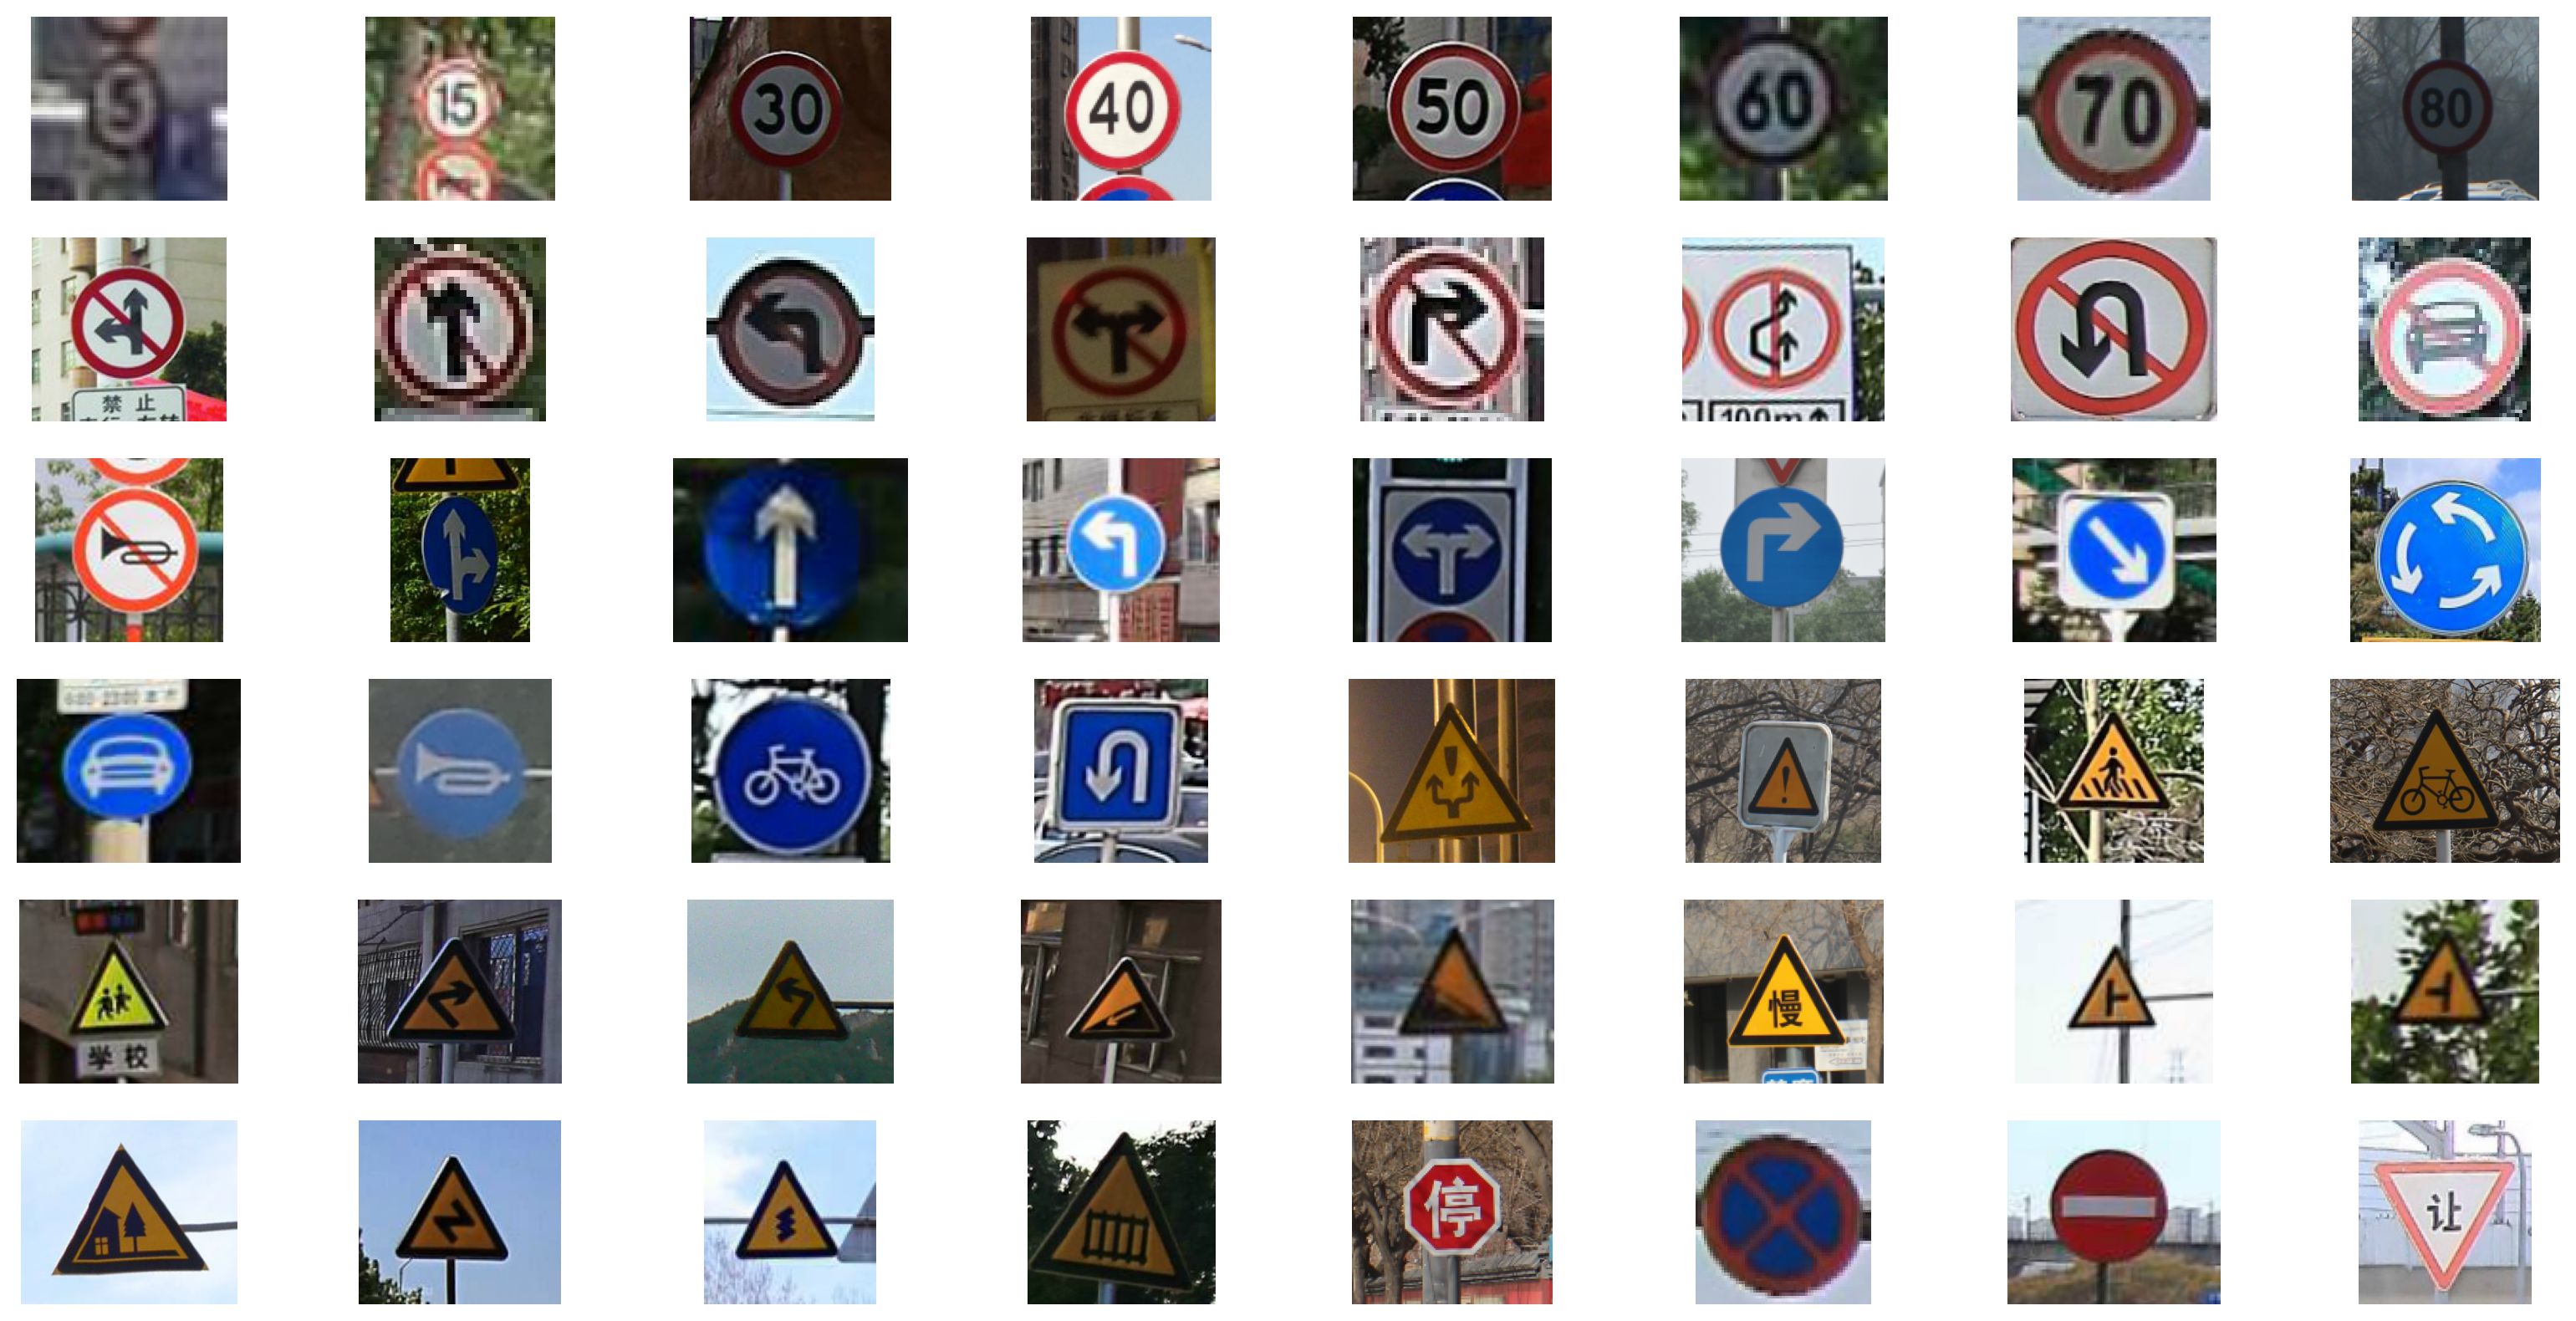

In [26]:
# создаем модельку
model, _, preprocess = open_clip.create_model_and_transforms('ViT-H-14-378-quickgelu', pretrained='dfn5b', device='cuda')

# давайте посмотрим на параметры модели
model.eval()
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Context length:", context_length)
print("Vocab size:", vocab_size)

all_test_files = []

for i in range(48):
    all_test_files += sorted(glob.glob(f'/kaggle/input/datasets/andreykurdyubov/signs-cv2/signs/TEST/{i}/*'))

test_classes = [int(x.split('/')[-2]) for x in all_test_files]
test_df = pd.DataFrame(zip(all_test_files, test_classes), columns=['imname', 'class'])

fig, ax = plt.subplots(6, 8, figsize=(20, 10))

for i in range(48):
    subset = test_df[test_df['class'] == i]
    imname = subset['imname'].values[:1][0]
    ax[i//8, i%8].imshow(cv2.imread(imname)[:, :, ::-1])
    ax[i//8, i%8].axis('off')


In [27]:
# заведем список с опциями классов
test_labels = [
    'number 5', 'number 15', 'number 30', 'number 40', 'number 50', 'number 60', 'number 70', 'number 80',
    'two arrows up and left crossed', 'arrow up crossed', 'arrow left crossed', 'two arrows to left and to right crossed', 'arrow right crossed', 'two arrows up crossed', 
    'arrow to behind crossed', 'car crossed', 'horn crossed', 'white arrow up and right', 'white arrow up', 'white arrow left', 'white arrow left and right',
    'white arrow right', 'white diagonal arrow right-down', 'three white arrows rotating anticlockwise', 'white car', 'white horn', 'white bicycle', 'white arrow to behind',
    'triangle with two arrows up by left and by right', 'triangle with exclamation mark !', 'pedestrian and zebra stripes', 'bicycle in triangle', 'running children in triangle',
    'arrow bottom--left-right in triangle', 'arrow bottom--right-left in triangle', 'triangle with median showing road slope to left', 
    'triangle with median showing road slope to right', 'yellow triangle with hieroglyph', 'yellow triangle with road up and right', 
    'yellow triangle with road up and left', 'yellow triangle with house and tree', 'yellow triangle with zigzag', 
    'yellow triangle with three stacking diagonal rectangles', 'yellow triangle with barrier', 'red octagon with hieroglyph',
    'double crossing - no stop', 'white bar - no entry', 'white triangle with hieroglyph'
]

# придумаем текстовые описания, которые будем показывать сети
text_descriptions = [f'a photo of a road sign with {label}' for label in test_labels]
text_descriptions, len(text_descriptions)

(['a photo of a road sign with number 5',
  'a photo of a road sign with number 15',
  'a photo of a road sign with number 30',
  'a photo of a road sign with number 40',
  'a photo of a road sign with number 50',
  'a photo of a road sign with number 60',
  'a photo of a road sign with number 70',
  'a photo of a road sign with number80',
  'a photo of a road sign with arrow up and left crossed',
  'a photo of a road sign with arrow up crossed',
  'a photo of a road sign with arrow left crossed',
  'a photo of a road sign with arrow left and right crossed',
  'a photo of a road sign with arrow right crossed',
  'a photo of a road sign with two arrows up crossed',
  'a photo of a road sign with arrow to behind crossed',
  'a photo of a road sign with car crossed',
  'a photo of a road sign with horn crossed',
  'a photo of a road sign with white arrow up and right',
  'a photo of a road sign with white arrow up',
  'a photo of a road sign with white arrow left',
  'a photo of a road si

In [28]:
# получим токены
text_tokens = tokenizer.tokenize(text_descriptions)

# текстовых описаний мало, для них мы один раз получим эмбеддинги
with torch.no_grad():
    text_features = model.encode_text(text_tokens.cuda()).float()

# обязательно их нормализуем, чтобы вектор оказался на едииничной сфере
text_features /= text_features.norm(dim=-1, keepdim=True)

# проверим размерности
print(text_features.shape)

# Теперь посчитаем эмбеддинги для всех наших картинок в test_df:
image_features = []

for i, row in tqdm.tqdm(test_df.iterrows()):
    image = Image.open(row['imname'])
    img_tensor = preprocess(image).unsqueeze(0).float()
    with torch.no_grad():
        image_feature = model.encode_image(img_tensor.cuda()).float()
    image_features += image_feature

# из листа делаем тензор
image_features = torch.stack(image_features)

# обязательно нормализуем
image_features /= image_features.norm(dim=-1, keepdim=True)

# проверим, что всё в  порядке
print(image_features.shape)

torch.Size([48, 1024])


1055it [07:14,  2.43it/s]

torch.Size([1055, 1024])


torch.Size([1055, 48])


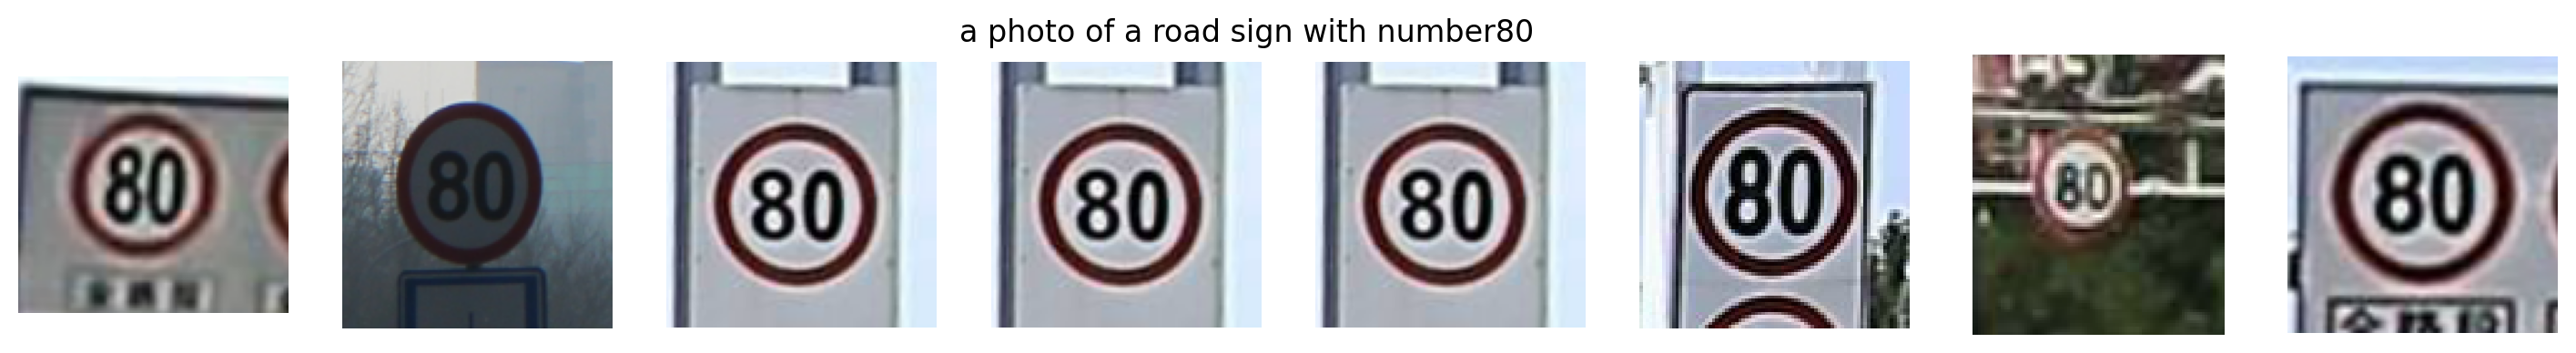

CLIP accuracy:  70.4265402843602


In [39]:
# по размерности текстов берем softmax - так мы распределим вероятности и сможем выбрать самый вероятный класс
text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print(text_probs.shape)

# по текстовой размерности выбираем максимальный элемент и его индекс
scores, preds = torch.max(text_probs, dim=-1)

test_df['pred'] = preds.cpu()
test_df['score'] = scores.cpu()

i = 7

fig, ax = plt.subplots(1, 8, figsize=(18, 2))
pred_df = test_df[test_df['pred'] == i] # выбираем картинки с предсказанным i-м классом
df_to_vis = pred_df.sample(8, replace=True)
df_to_vis.reset_index(inplace=True, drop=True)

for j, row in df_to_vis.iterrows():
    image = cv2.imread(row['imname'])
    ax[j].imshow(image[:, :, ::-1])
    ax[j].axis("off")
    
plt.suptitle(text_descriptions[i])
plt.show()

print('CLIP accuracy: ', 100 * accuracy_score(test_df['class'], test_df['pred']))

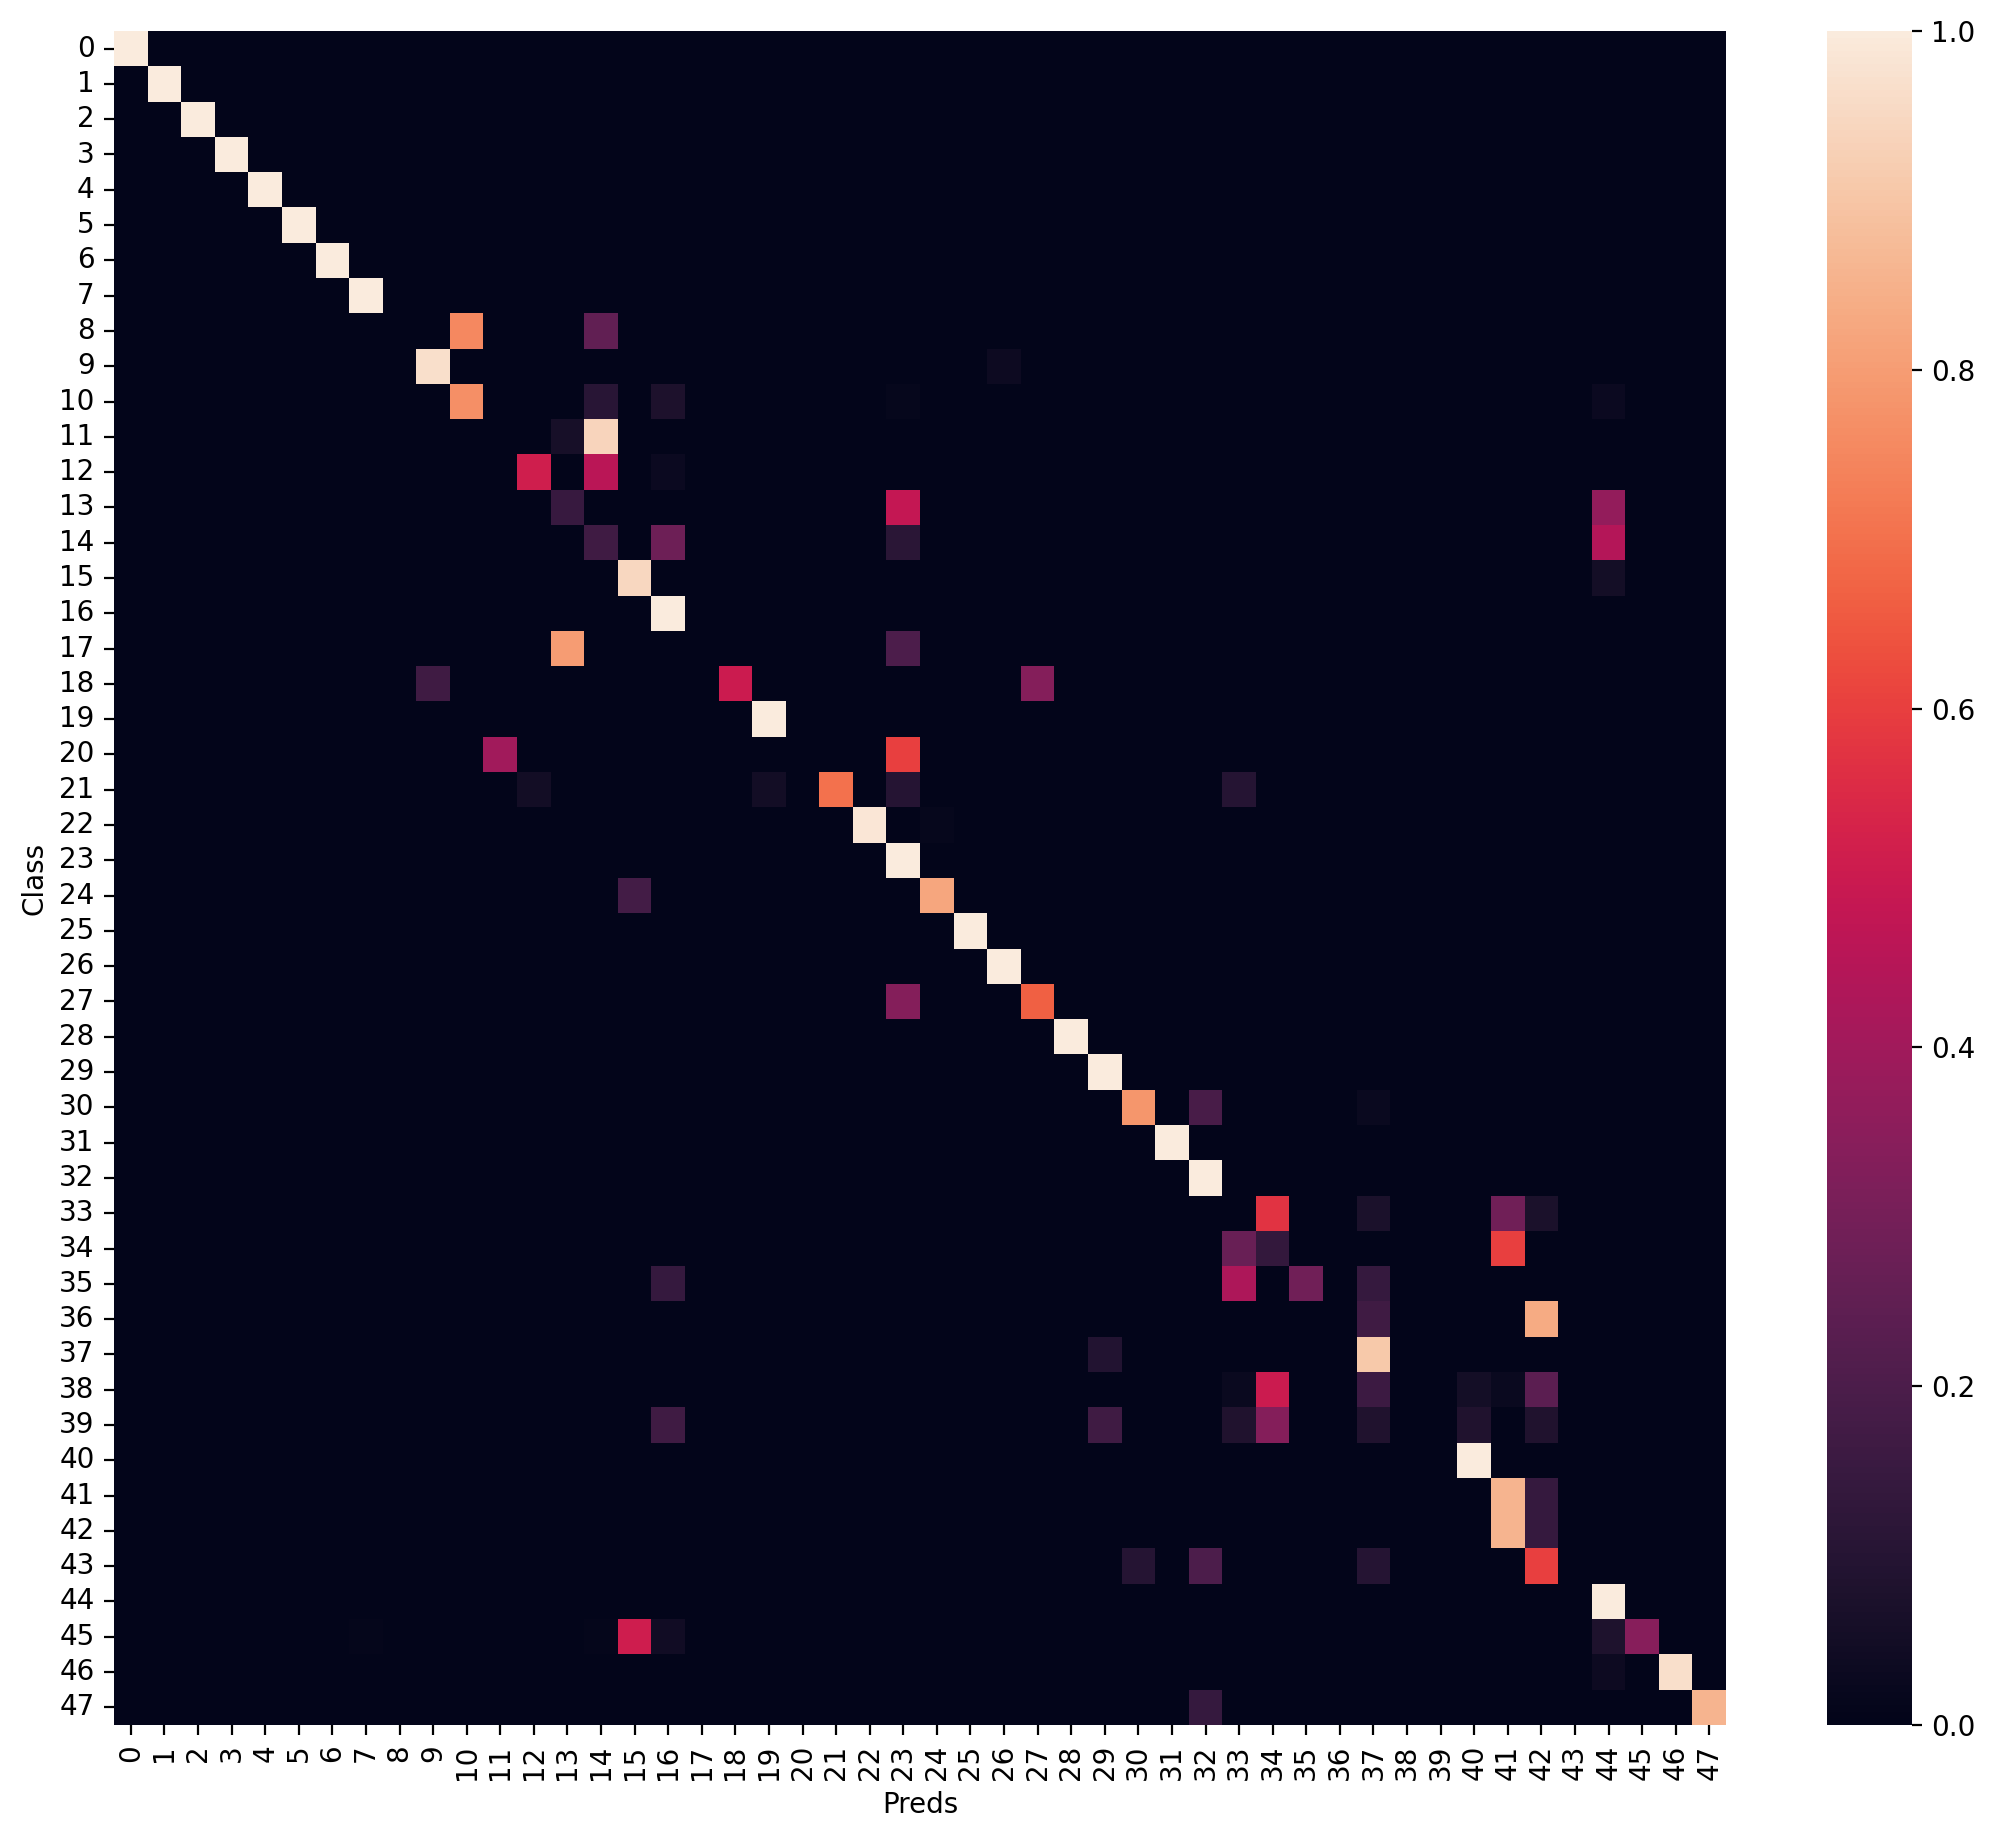

In [44]:
cm = confusion_matrix(test_df['class'], test_df['pred'], normalize='true')
                                
plt.figure(figsize = (13, 11))
ax = sn.heatmap(cm)
ax.set(xlabel='Preds', ylabel='Class')
plt.show()